# Batched whole-body controller (WBC) for robot arms

A **whole-body controller (WBC)** turns a desired motion into joint torques by solving a small
**quadratic program (QP)** at every control tick. This notebook runs a thousand of them for the
[Franka Emika Panda](https://github.com/google-deepmind/mujoco_menagerie/tree/main/franka_emika_panda)
entirely on the GPU, with two [Warp](https://github.com/NVIDIA/warp)-based libraries:

- [**Newton**](https://github.com/newton-physics/newton) builds the robots, simulates them (here with
  its MuJoCo solver), evaluates their dynamics -- mass matrix, Coriolis and gravity forces,
  Jacobians -- and visualizes them;
- **cuPIQP** solves the WBC QPs of all arms in one batched call.

A Warp kernel of our own sits in between and assembles every arm's QP from Newton's arrays. Since
both libraries keep their data in `warp.array`s, nothing is copied between them and nothing goes
through the host -- so the whole control tick, physics included, is recorded **once** into a CUDA
graph with `wp.ScopedCapture` and replayed.

1. **A batch of random WBC problems**, built from Newton and solved in one call, with a feasibility
   check and a scaling study.
2. **Closed loop in one CUDA graph**: 1024 simulated Pandas each track their own figure-eight at
   500 Hz.
3. **A video** of the arms, rendered with Newton's OpenGL viewer.

To run this notebook, you will need [Newton](https://github.com/newton-physics/newton) with its
simulation extras, [robot_descriptions](https://github.com/robot-descriptions/robot_descriptions.py)
(it downloads MuJoCo Menagerie on first use), [mediapy](https://github.com/google/mediapy) together
with `ffmpeg`, and [pyglet](https://pyglet.org) for the viewer.

In [1]:
%%capture
# Restart the kernel after installing or updating packages.
%pip install "newton[sim]" robot_descriptions mediapy pyglet

In [2]:
import os
import time
import xml.etree.ElementTree as ET
import numpy as np
import warp as wp
import matplotlib
import matplotlib.pyplot as plt
import mediapy as media
import newton
%matplotlib inline
%config InlineBackend.figure_format='retina'

from robot_descriptions import panda_mj_description

from cupiqp import DenseSolver, Status

print("GPU:", wp.get_device("cuda").name, "  Newton:", newton.__version__, "  Warp:", wp.__version__)

GPU: NVIDIA GeForce RTX 5090   Newton: 1.6.0   Warp: 1.17.0


## The robot-arm WBC QP

For a fixed-base arm with $n_a$ actuated joints, with joint positions $q$ and generalized velocity
$\nu$, one WBC tick solves

<!-- $$
\min_{x}\;\; \tfrac12\, x^\top P\, x + c^\top x
\quad\text{s.t.}\quad
A x = b,\qquad x_\ell \le x \le x_u ,
$$ -->

$$
\begin{aligned}
	\min_{\dot \nu, \tau} \quad &
		\lVert J_{tcp}\,\dot \nu - b_{tcp}\rVert^2_{W}
		+ w_{\mathrm{post}}\lVert\dot \nu-\dot \nu_{\mathrm{ref}}\rVert^2
		+ w_\tau\lVert\tau\rVert^2
		+ \varepsilon\lVert \dot \nu \rVert^2 + \varepsilon\lVert \tau \rVert^2 \\
	\text{s.t.} \quad & M(q)\, \dot \nu + \mathrm{nle}(q,\nu) = \tau, \\
			& -\tau_{\lim}\le \tau \le \tau_{\lim},
\end{aligned}
$$

with the decision variables the joint **accelerations** $\dot \nu \in\mathbb{R}^{n_a}$ and **torques**
$\tau \in\mathbb{R}^{n_a}$. The equality is the equation of motion: $M(q)$ is the joint-space inertia
matrix and $\mathrm{nle}(q,\nu)$ collects Coriolis, gravity and joint damping, evaluated at the joint
position $q$ and velocity $\nu$. The torque limits are per-variable bounds.

### Where the end-effector tracking term comes from

The end-effector is the tool center point (TCP) between the fingertips. Its position $p(q)$ and
orientation $R(q)$ follow from the joint positions by forward kinematics, and its linear and angular
velocity are linear in the generalized velocity:

$$
\begin{bmatrix} \dot p \\ \omega \end{bmatrix} = J_{tcp}(q)\,\nu,
\qquad
J_{tcp} = \begin{bmatrix} J_p \\ J_R \end{bmatrix} \in \mathbb{R}^{6\times n_a},
$$

with $J_p$ and $J_R$ the linear and angular parts of the TCP Jacobian. Differentiating once more in
time gives the TCP acceleration,

$$
\begin{bmatrix} \ddot p \\ \dot\omega \end{bmatrix} = J_{tcp}(q)\,\dot \nu + \dot J_{tcp}(q,\nu)\,\nu ,
$$

which is **affine in the decision variable** $\dot \nu$: at a given state, $J_{tcp}$ and the bias
term $\dot J_{tcp}\nu$ are known numbers.

The task is to follow a desired end-effector trajectory -- position $p_{\mathrm{EE}}(t)$, velocity
$v_{\mathrm{EE}}(t)$ and acceleration $a_{\mathrm{EE}}(t)$ -- while holding a desired orientation
$R_{\mathrm{EE}}$ (gripper pointing down). A PD law around the trajectory gives the TCP acceleration we
would like to have:

$$
a^{\mathrm{des}} =
\begin{bmatrix}
a_{\mathrm{EE}} + K_p\,(p_{\mathrm{EE}} - p) + K_d\,(v_{\mathrm{EE}} - J_p\,\nu) \\
K_p\, e_R - K_d\, J_R\,\nu
\end{bmatrix},
$$

where $e_R$ is the axis-angle vector of the rotation $R_{\mathrm{EE}} R^\top$ that takes the current
orientation to the desired one. If the TCP had exactly this acceleration, the position error
$e = p_{\mathrm{EE}} - p$ would obey

$$
\ddot e + K_d\,\dot e + K_p\, e = 0 ,
$$

so it decays exponentially; with $K_p = 400$ and $K_d = 40 = 2\sqrt{K_p}$ it is critically damped. The
orientation error behaves the same way.

The robot cannot always produce $a^{\mathrm{des}}$ exactly: the accelerations must be consistent with
the dynamics and the torque limits, and other tasks compete for them. So instead of imposing it as a
constraint, we ask for it in the least-squares sense and penalize the difference between the actual
and the desired TCP acceleration,

$$
\Big\lVert J_{tcp}\,\dot \nu + \dot J_{tcp}\,\nu - a^{\mathrm{des}} \Big\rVert^2_{W},
$$

with weights $W = \mathrm{diag}(w_p I_3,\, w_R I_3)$ that trade position against orientation errors.

**Dropping the velocity-product term.** The bias term $\dot J_{tcp}\,\nu$ is
small when the arm moves slowly. Newton evaluates $J_{tcp}$ but not its time derivative, so in this
notebook we neglect the term and use

$$
\lVert J_{tcp}\,\dot \nu - b_{tcp}\rVert^2_{W},
\qquad
b_{tcp} = a^{\mathrm{des}} .
$$

The PD feedback in $a^{\mathrm{des}}$ absorbs the neglected acceleration, at the price of a somewhat
larger tracking error in the faster parts of the motion.

### The other terms

- posture regularization $\;w_{\mathrm{post}}\lVert\dot \nu-\dot \nu_{\mathrm{ref}}\rVert^2$ with
  $\dot \nu_{\mathrm{ref}}=-K^{\mathrm{post}}_p(q-q_{\mathrm{home}})-K^{\mathrm{post}}_d \nu$: the arm
  has 7 joints for a 6-dimensional task, and this term uses the remaining freedom to stay close to
  the home posture;
- torque regularization $\;w_\tau\lVert\tau\rVert^2$;
- a tiny regularization term $\varepsilon\lVert \dot \nu \rVert^2 + \varepsilon\lVert \tau \rVert^2$ that
  keeps the problem strictly convex.

### The QP data

With $x = [\dot \nu;\, \tau]$, the cost is quadratic and the constraints are linear, so the problem is a
QP. Halving the cost (which does not change the minimizer) and expanding the squares gives

$$
P = \begin{bmatrix} J_{tcp}^\top W J_{tcp} + (w_{\mathrm{post}} + \varepsilon) I & 0 \\ 0 & (w_\tau + \varepsilon) I \end{bmatrix},
\qquad
c = \begin{bmatrix} -J_{tcp}^\top W\, b_{tcp} - w_{\mathrm{post}}\, \dot \nu_{\mathrm{ref}} \\ 0 \end{bmatrix},
$$

$$
A = \begin{bmatrix} M(q) & -I \end{bmatrix}, \qquad b = -\,\mathrm{nle}(q, \nu), \qquad
x_\ell = \begin{bmatrix} -\infty \\ -\tau_{\lim} \end{bmatrix}, \quad
x_u = \begin{bmatrix} +\infty \\ \tau_{\lim} \end{bmatrix}.
$$

In the code, the desired trajectory $p_{\mathrm{EE}}, v_{\mathrm{EE}}, a_{\mathrm{EE}}$ and orientation
$R_{\mathrm{EE}}$ are the arrays `p_des`, `v_des`, `a_ff` and `R_des`.

## The Panda in Newton

Newton's `ModelBuilder` imports the Panda straight from its MuJoCo Menagerie MJCF file. Two small
edits of the XML make it a torque-controlled 7-joint arm: the finger joints are removed, so the
gripper is rigidly closed, together with their coupling, the built-in position servos and the
keyframe. Newton then imports the joint armature and damping of the file, and the joints are driven
by the joint torques in `control.joint_f`.

`builder.replicate(arm, B)` copies the arm into `B` independent **worlds** -- one per QP of the
batch -- and `finalize()` puts the model on the GPU. The ground plane is only for display.

In [3]:
def panda_mjcf():
    # The Menagerie Panda as a torque-controlled 7-joint arm with a rigid, closed gripper.
    path = panda_mj_description.MJCF_PATH
    root = ET.parse(path).getroot()
    root.find("compiler").set("meshdir", os.path.join(os.path.dirname(path), "assets"))
    for parent in root.iter():
        for child in list(parent):
            if child.tag == "joint" and child.get("name", "").startswith("finger_joint"):
                parent.remove(child)
    for tag in ("tendon", "equality", "actuator", "keyframe"):
        for element in root.findall(tag):
            root.remove(element)
    return ET.tostring(root, encoding="unicode")


arm = newton.ModelBuilder()
arm.add_mjcf(panda_mjcf())


def build_model(B):
    builder = newton.ModelBuilder()
    builder.replicate(arm, B)
    builder.add_ground_plane()
    return builder.finalize()


na = arm.joint_dof_count                  # actuated joints
n_dec = 2 * na                            # decision variables: [nu_dot; tau]
NB = arm.body_count                       # bodies per arm
HAND = next(i for i, label in enumerate(arm.body_label) if label.endswith("/hand"))
TCP_OFFSET = wp.constant(wp.vec3(0.0, 0.0, 0.1034))   # tool center point between the fingertips, in the hand frame
DT = 0.002                                # 500 Hz control

# Panda datasheet torque limits (N*m) and the "home" posture of the Menagerie model.
TAU_LIM = np.array([87., 87., 87., 87., 12., 12., 12.])
Q_HOME = np.array([0.0, 0.0, 0.0, -1.57079, 0.0, 1.57079, -0.7853])

print(f"Franka Panda: {na} joints, {NB} bodies, armature {arm.joint_armature[0]}, damping {arm.joint_damping[0]}")

Franka Panda: 7 joints, 11 bodies, armature 0.1, damping 1.0


## The WBC terms from Newton -- and one kernel to assemble the QPs

We use Newton to evaluate everything the QP needs for all arms, i.e., the `P`, `c`, `A`, `b` fields.

<!-- | QP term | Newton |
|---|---|
| link poses | `newton.eval_fk` |
| $M(q)$ | `newton.eval_inverse_dynamics_passive(mass_matrix=...)`, plus the joint armature |
| $C(q,\nu)\,\nu + g(q)$ | `newton.eval_inverse_dynamics_passive(coriolis_force=..., gravity_force=...)` |
| $D\,\nu$ | `model.joint_damping` times the joint velocity |
| $J_{tcp}$ | `newton.eval_jacobian` -- each link's twist at its center of mass, moved to the TCP | -->

Newton computes in float32; the QPs are float64 for cuPIQP. The torque block of `P` and the $-I$ block of
`A` never change, so they are written once when the arrays are allocated.

The `WholeBodyController` class wraps it all for a batch of arms: it holds the desired motion of every
arm, assembles their QPs with `assemble(state)`, and `solve(state)` also solves them in one batched
cuPIQP call.

In [4]:
# Task weights and PD gains (shared across the batch).
W_POS, W_ROT, W_POST, W_TAU, W_REG = 100.0, 10.0, 1.0, 1e-3, 1e-6
KP_EE, KD_EE = 400.0, 40.0
KP_POSTURE, KD_POSTURE = 25.0, 10.0

Below are some helpers.

In [5]:
@wp.func
def tcp_jacobian_column(
    J: wp.array3d(dtype=float),            # type: ignore  # Jacobians of all arms from newton.eval_jacobian, (B, links * 6, na)
    body_q: wp.array(dtype=wp.transform),  # type: ignore  # world poses of all bodies, at the configuration of J
    body_com: wp.array(dtype=wp.vec3),     # type: ignore  # center of mass of every body, in the body frame
    w: int,                                # type: ignore  # arm (world) index
    j: int,                                # type: ignore  # joint index
):
    """Column ``j`` of arm ``w``'s TCP Jacobian: linear part (at the TCP) and angular part, in
    the world frame.
    """
    X = body_q[w * NB + HAND]
    r = wp.transform_point(X, TCP_OFFSET) - wp.transform_point(X, body_com[w * NB + HAND])
    row = HAND * 6
    lin = wp.vec3(J[w, row + 0, j], J[w, row + 1, j], J[w, row + 2, j])
    ang = wp.vec3(J[w, row + 3, j], J[w, row + 4, j], J[w, row + 5, j])
    return lin + wp.cross(ang, r), ang


@wp.func
def tcp_velocity(
    J: wp.array3d(dtype=float),            # type: ignore  # Jacobians of all arms from newton.eval_jacobian, (B, links * 6, na)
    body_q: wp.array(dtype=wp.transform),  # type: ignore  # world poses of all bodies, at the configuration of J
    body_com: wp.array(dtype=wp.vec3),     # type: ignore  # center of mass of every body, in the body frame
    joint_qd: wp.array(dtype=float),       # type: ignore  # generalized velocities nu of all arms, (B * na,)
    w: int,                                # type: ignore  # arm (world) index
):
    """Linear and angular velocity of arm ``w``'s TCP, ``J_tcp(q) nu``, in the world frame."""
    v_lin = wp.vec3(0.0)
    v_ang = wp.vec3(0.0)
    for j in range(na):
        lin, ang = tcp_jacobian_column(J, body_q, body_com, w, j)
        v_lin += lin * joint_qd[w * na + j]
        v_ang += ang * joint_qd[w * na + j]
    return v_lin, v_ang


@wp.kernel
def tcp_pose(
    body_q: wp.array(dtype=wp.transform),  # type: ignore  # world poses of all bodies, from newton.eval_fk
    p: wp.array(dtype=wp.vec3),            # type: ignore  # output: TCP position of every arm, (B,)
    R: wp.array(dtype=wp.mat33),           # type: ignore  # output: TCP orientation (body-to-world rotation) of every arm, (B,)
):
    """Position and orientation of every arm's TCP. Launch with ``dim = B``."""
    w = wp.tid()
    X = body_q[w * NB + HAND]
    p[w] = wp.transform_point(X, TCP_OFFSET)
    R[w] = wp.quat_to_matrix(wp.transform_get_rotation(X))


@wp.kernel
def build_wbc_qp(
    # Newton model and state
    joint_q: wp.array(dtype=float),         # type: ignore  # joint positions q of all arms, (B * na,)
    joint_qd: wp.array(dtype=float),        # type: ignore  # generalized velocities nu of all arms, (B * na,)
    joint_armature: wp.array(dtype=float),  # type: ignore  # joint armature, added to the diagonal of M, (B * na,)
    joint_damping: wp.array(dtype=float),   # type: ignore  # joint damping D, (B * na,)
    M: wp.array3d(dtype=float),             # type: ignore  # mass matrices without armature, (B, na, na)
    coriolis: wp.array(dtype=float),        # type: ignore  # Coriolis forces C(q, nu) nu, (B * na,)
    gravity: wp.array(dtype=float),         # type: ignore  # gravity forces g(q), (B * na,)
    body_com: wp.array(dtype=wp.vec3),      # type: ignore  # center of mass of every body, in the body frame
    body_q: wp.array(dtype=wp.transform),   # type: ignore  # world poses of all bodies at q
    J: wp.array3d(dtype=float),             # type: ignore  # Jacobians of all arms at q, (B, links * 6, na)
    # task targets, one per arm
    q_home: wp.array(dtype=float),          # type: ignore  # home posture for the posture task, (na,)
    p_des: wp.array(dtype=wp.vec3),         # type: ignore  # desired TCP position p_EE, (B,)
    v_des: wp.array(dtype=wp.vec3),         # type: ignore  # desired TCP velocity v_EE, (B,)
    a_ff: wp.array(dtype=wp.vec3),          # type: ignore  # feedforward TCP acceleration a_EE, (B,)
    R_des: wp.array(dtype=wp.mat33),        # type: ignore  # desired TCP orientation R_EE, (B,)
    # QP data (float64), written in place
    P: wp.array3d(dtype=wp.float64),        # type: ignore  # output: QP cost matrices, (B, 2 na, 2 na)
    c: wp.array2d(dtype=wp.float64),        # type: ignore  # output: QP cost vectors, (B, 2 na)
    A: wp.array3d(dtype=wp.float64),        # type: ignore  # output: equality matrices [M, -I], (B, na, 2 na)
    b: wp.array2d(dtype=wp.float64),        # type: ignore  # output: equality right-hand sides -nle, (B, na)
):
    """Write the state- and task-dependent blocks of every arm's WBC QP from Newton's dynamics,
    with ``b_tcp = a_des`` (``dJ_tcp/dt nu`` neglected). Launch with ``dim = B``.
    """
    w = wp.tid()
    X = body_q[w * NB + HAND]
    p = wp.transform_point(X, TCP_OFFSET)

    # TCP velocity J nu
    v_lin, v_ang = tcp_velocity(J, body_q, body_com, joint_qd, w)

    # orientation error: axis-angle vector of R_des R^T
    E = R_des[w] * wp.transpose(wp.quat_to_matrix(wp.transform_get_rotation(X)))
    e_rot = 0.5 * wp.vec3(E[2, 1] - E[1, 2], E[0, 2] - E[2, 0], E[1, 0] - E[0, 1])
    s = wp.length(e_rot)
    if s > 1.0e-9:
        e_rot = e_rot * (wp.atan2(s, 0.5 * (E[0, 0] + E[1, 1] + E[2, 2] - 1.0)) / s)

    # task right-hand side b_tcp = a_des (the velocity-product term dJ/dt nu is neglected)
    b_lin = a_ff[w] + KP_EE * (p_des[w] - p) + KD_EE * (v_des[w] - v_lin)
    b_ang = KP_EE * e_rot - KD_EE * v_ang

    for i in range(na):
        lin_i, ang_i = tcp_jacobian_column(J, body_q, body_com, w, i)
        for j in range(na):
            lin_j, ang_j = tcp_jacobian_column(J, body_q, body_com, w, j)
            p_ij = W_POS * wp.dot(lin_i, lin_j) + W_ROT * wp.dot(ang_i, ang_j)   # J^T W J
            m_ij = M[w, i, j]
            if i == j:
                p_ij += W_POST + W_REG
                m_ij += joint_armature[w * na + i]
            P[w, i, j] = wp.float64(p_ij)
            A[w, i, j] = wp.float64(m_ij)
        k = w * na + i
        nu_dot_ref = -KP_POSTURE * (joint_q[k] - q_home[i]) - KD_POSTURE * joint_qd[k]
        c[w, i] = wp.float64(-(W_POS * wp.dot(lin_i, b_lin) + W_ROT * wp.dot(ang_i, b_ang)) - W_POST * nu_dot_ref)
        b[w, i] = wp.float64(-(coriolis[k] + gravity[k] + joint_damping[k] * joint_qd[k]))



In [6]:
class WholeBodyController:
    """Batched whole-body controller for the Panda arms of a Newton model.

    One controller handles all ``B`` arms of the model, one per world. It
    holds the desired TCP motion of every arm, assembles their WBC QPs from
    Newton's dynamics with ``build_wbc_qp``, and solves all of them in one
    batched cuPIQP call. Every array is allocated here, once, so ``assemble``
    and ``solve`` only launch GPU work and can be recorded into a CUDA graph.
    Typical use::

        wbc = WholeBodyController(model)
        wbc.p_des.assign(...)       # desired TCP motion of every arm
        wbc.solve(state)            # QPs at `state`, solved on the GPU
        wbc.solver.result.x         # [nu_dot; tau] of every arm

    Parameters
    ----------
    model : newton.Model
        ``B`` Panda arms, one per world, from ``build_model``.

    Attributes
    ----------
    p_des, v_des, a_ff : wp.array(dtype=wp.vec3)
        Desired TCP position ``p_EE``, velocity ``v_EE`` and feedforward
        acceleration ``a_EE`` of every arm, shape ``(B,)``. Zero at
        construction; write them before ``assemble`` or ``solve``.
    R_des : wp.array(dtype=wp.mat33)
        Desired TCP orientation ``R_EE`` of every arm, shape ``(B,)``. Identity
        at construction.
    P, c, A, b : wp.array(dtype=wp.float64)
        QP data of every arm, shapes ``(B, 2 na, 2 na)``, ``(B, 2 na)``,
        ``(B, na, 2 na)`` and ``(B, na)``, written by ``assemble``.
    x_l, x_u : wp.array(dtype=wp.float64)
        Box bounds, shape ``(2 na,)``, shared by every arm: the torque limits
        on ``tau``, with ``nu_dot`` unbounded.
    solver : cupiqp.DenseSolver
        The QP solver. After ``solve``, ``solver.result.x`` holds the solution
        ``[nu_dot; tau]`` of every arm and ``solver.result.info.status`` its
        status.
    """

    def __init__(self, model):
        self.model = model
        B = model.articulation_count

        # Desired TCP motion of every arm.
        self.p_des = wp.zeros(B, dtype=wp.vec3)
        self.v_des = wp.zeros(B, dtype=wp.vec3)
        self.a_ff = wp.zeros(B, dtype=wp.vec3)
        self.R_des = wp.from_numpy(np.tile(np.eye(3), (B, 1, 1)), dtype=wp.mat33)

        # QP data. The blocks that never change are filled here, once: the torque block
        # (w_tau + eps) I of P, the -I block of A, and the box bounds.
        P = np.zeros((B, n_dec, n_dec))
        P[:, na:, na:] = (W_TAU + W_REG) * np.eye(na)
        A = np.zeros((B, na, n_dec))
        A[:, :, na:] = -np.eye(na)
        self.P = wp.from_numpy(P, dtype=wp.float64)
        self.c = wp.zeros((B, n_dec), dtype=wp.float64)
        self.A = wp.from_numpy(A, dtype=wp.float64)
        self.b = wp.zeros((B, na), dtype=wp.float64)
        self.x_l = wp.from_numpy(np.concatenate([np.full(na, -np.inf), -TAU_LIM]), dtype=wp.float64)
        self.x_u = wp.from_numpy(np.concatenate([np.full(na, +np.inf), +TAU_LIM]), dtype=wp.float64)

        # Scratch arrays for Newton's dynamics.
        self._q_home = wp.array(Q_HOME, dtype=float)
        self._M = wp.zeros((B, na, na), dtype=float)
        self._coriolis = wp.zeros(model.joint_dof_count, dtype=float)
        self._gravity = wp.zeros(model.joint_dof_count, dtype=float)
        self._J = wp.zeros((B, model.max_joints_per_articulation * 6, na), dtype=float)

        # Keep the Ruiz scaling computed at setup when the data is updated: the fresh scaling of
        # every update checks its convergence on the host, which a CUDA graph cannot do.
        self.solver = DenseSolver()
        self.solver.settings.verbose = False
        self.solver.settings.preconditioner_reuse_on_update = True
        self._solver_ready = False

    def assemble(self, state):
        """Evaluate the dynamics at ``state`` and write the QP of every arm.

        Runs forward kinematics (updating ``state.body_q`` in place), the mass
        matrix, Coriolis and gravity forces, and the Jacobians at ``q``, then
        launches ``build_wbc_qp``, which writes ``P``, ``c``, ``A`` and ``b``.

        Parameters
        ----------
        state : newton.State
            Joint positions and velocities of all arms.
        """
        m = self.model
        newton.eval_fk(m, state.joint_q, state.joint_qd, state)
        newton.eval_inverse_dynamics_passive(m, state, mass_matrix=self._M,
                                             coriolis_force=self._coriolis, gravity_force=self._gravity)
        newton.eval_jacobian(m, state, self._J)
        wp.launch(build_wbc_qp, dim=m.articulation_count,
                  inputs=[state.joint_q, state.joint_qd, m.joint_armature, m.joint_damping,
                          self._M, self._coriolis, self._gravity, m.body_com, state.body_q, self._J,
                          self._q_home, self.p_des, self.v_des, self.a_ff, self.R_des],
                  outputs=[self.P, self.c, self.A, self.b])

    def solve(self, state):
        """Assemble the QPs at ``state`` and solve them in one batched call.

        The first call sets up the solver, which allocates its GPU memory and
        must therefore happen outside a CUDA graph capture; later calls only
        update the QP data and solve, and can be captured. The solve is
        asynchronous: the results in ``solver.result`` are ready for any work
        queued afterwards on ``solver.stream``.

        Parameters
        ----------
        state : newton.State
            Joint positions and velocities of all arms.
        """
        self.assemble(state)
        if self._solver_ready:
            self.solver.update(P=self.P, c=self.c, A=self.A, b=self.b)
        else:
            self.solver.setup(P=self.P, c=self.c, A=self.A, b=self.b, x_l=self.x_l, x_u=self.x_u)
            self._solver_ready = True
        self.solver.solve()


## Part 1 -- a batch of random WBC problems

We build a model with $B$ arms, put them at random states near the home posture, give each a nearby
TCP target (holding its current orientation) and let a `WholeBodyController` assemble all QPs. The arrays have
the batch as their leading axis -- the layout cuPIQP's dense batched solver expects.

In [7]:
B_MAX = 8192
model = build_model(B_MAX)
state = model.state()
rng = np.random.default_rng(0)

# Random states near home (clipped to stay away from kinematic singularities).
q = Q_HOME + np.clip(rng.standard_normal((B_MAX, na)), -2, 2) * 0.3
v = np.clip(rng.standard_normal((B_MAX, na)), -2, 2) * 0.5
state.joint_q.assign(q.ravel())
state.joint_qd.assign(v.ravel())
newton.eval_fk(model, state.joint_q, state.joint_qd, state)

# A nearby TCP target with a random velocity for every arm, holding its current orientation.
wbc = WholeBodyController(model)
p_now = wp.zeros(B_MAX, dtype=wp.vec3)
wp.launch(tcp_pose, dim=B_MAX, inputs=[state.body_q], outputs=[p_now, wbc.R_des])
wbc.p_des.assign(p_now.numpy() + rng.uniform(-0.05, 0.05, (B_MAX, 3)))
wbc.v_des.assign(rng.uniform(-0.2, 0.2, (B_MAX, 3)))

wbc.assemble(state)
print(f"assembled {B_MAX} WBC QPs on the GPU")

assembled 8192 WBC QPs on the GPU


### Solve a batch in one GPU call

The QP arrays are already Warp arrays on the GPU: hand them to `DenseSolver` and call `solve()`
**once** -- every problem in the batch is solved together. The torque box is the same for every
problem, so `x_l` and `x_u` are passed *shared*, with the shape of a single problem. With
`verbose=True` the solver prints its problem sizes and a log of the interior-point iterations.

In [8]:
B = 1024
# Solve the first B problems of wbc; verbose=True prints the solver's per-iteration log.
solver = DenseSolver()
solver.settings.verbose = True
# setup: per-problem (B, ...) data and shared (n,) bounds; B is read from the leading axis
solver.setup(P=wbc.P[:B], c=wbc.c[:B], A=wbc.A[:B], b=wbc.b[:B], x_l=wbc.x_l, x_u=wbc.x_u)
solver.solve()
wp.synchronize()
status = solver.result.info.status.numpy()
n_iter = solver.result.info.iter.numpy()
print(f"Solved {(status == Status.CUPIQP_SOLVED.value).sum()} / {B} WBC problems in a single batched call.")
print(f"IPM iterations across the batch: min={n_iter.min()}, max={n_iter.max()}")

----------------------------------------------------------
       cuPIQP v0.1.0 - GPU-accelerated PIQP solver        
                    (c) Fenglong Song                     
   Ecole Polytechnique Federale de Lausanne (EPFL) 2026   
----------------------------------------------------------
dense backend:
batch size B = 1024
variables n = 14
equality constraints p = 7
inequality constraints m = 0
inequality lower bounds n_h_l = 0
inequality upper bounds n_h_u = 0
variable lower bounds n_x_l = 14
variable upper bounds n_x_u = 14

iter     solved       gap_max     p_res_max     d_res_max     rho_max   delta_max      mu_max  p_step  d_step
   0     0/1024   3.76466e+04   1.68136e+02   1.98480e+02   1.000e-06   1.000e-04   1.704e+04  0.0000  0.0000


   1     0/1024   1.29977e+04   4.89210e+01   1.17309e+02   5.000e-07   1.000e-05   4.045e+03  0.6646  0.9747


   2     0/1024   6.92033e+03   8.07601e+00   1.20092e+02   5.000e-08   1.000e-06   5.274e+02  0.4773  0.8805


   3     0/1024   1.22984e+04   8.18207e-02   2.29704e+02   5.000e-09   1.000e-07   9.486e+02  0.8940  0.4729


   4     0/1024   2.65929e+03   4.86354e-03   3.54036e+01   5.000e-10   1.000e-08   1.968e+02  0.8329  0.9896


...

   7  1015/1024   1.89783e-02   5.85794e-08   2.35161e-04   1.000e-10   1.000e-09   1.687e-03  0.9899  0.9900


   8  1023/1024   2.48792e-04   5.85794e-08   2.35163e-06   1.000e-10   1.000e-09   1.728e-05  0.9900  0.9900



Finished in 9 iterations


  Solved:              1024/1024


Solved 1024 / 1024 WBC problems in a single batched call.
IPM iterations across the batch: min=5, max=9


### Check the solutions are feasible

`solver.result.x` is a `(B, n)` warp array -- one solution per problem. We verify the
equation-of-motion equality and the torque box on the host.

In [9]:
x = solver.result.x.numpy()              # (B, n)
A_np, b_np = wbc.A.numpy()[:B], wbc.b.numpy()[:B]
x_l, x_u = wbc.x_l.numpy(), wbc.x_u.numpy()

eq_res = np.abs(np.einsum("bij,bj->bi", A_np, x) - b_np).max(axis=1)
box_viol = np.maximum(np.maximum(x_l - x, x - x_u), 0.0).max(axis=1)    # +/-inf bounds give 0

print(f"max |M nu_dot - tau + nle| over the batch : {eq_res.max():.2e}")
print(f"max torque-box violation   over the batch : {box_viol.max():.2e}")

max |M nu_dot - tau + nle| over the batch : 2.83e-09
max torque-box violation   over the batch : 3.94e-08


### Scaling: how throughput grows with the batch

The whole point of batching: a single-thread CPU solver pays *linearly* for every extra problem,
while the GPU solver amortizes launch and orchestration overhead across the batch. cuPIQP also
records the interior-point iteration as a CUDA graph and replays it, so repeated solves are cheap.
We sweep the batch size and measure

$$
\text{throughput}(B) = \frac{B}{t_{\text{solve}}(B)}\quad[\text{QPs / second}].
$$

B=    64:  solve =     1.57 ms   ->        40712 QPs/s
B=   128:  solve =     1.77 ms   ->        72235 QPs/s
B=   256:  solve =     1.86 ms   ->       137544 QPs/s
B=   512:  solve =     2.20 ms   ->       232607 QPs/s
B=  1024:  solve =     3.36 ms   ->       304451 QPs/s


B=  2048:  solve =     5.08 ms   ->       403067 QPs/s


B=  4096:  solve =     9.91 ms   ->       413154 QPs/s


B=  8192:  solve =    17.81 ms   ->       459853 QPs/s


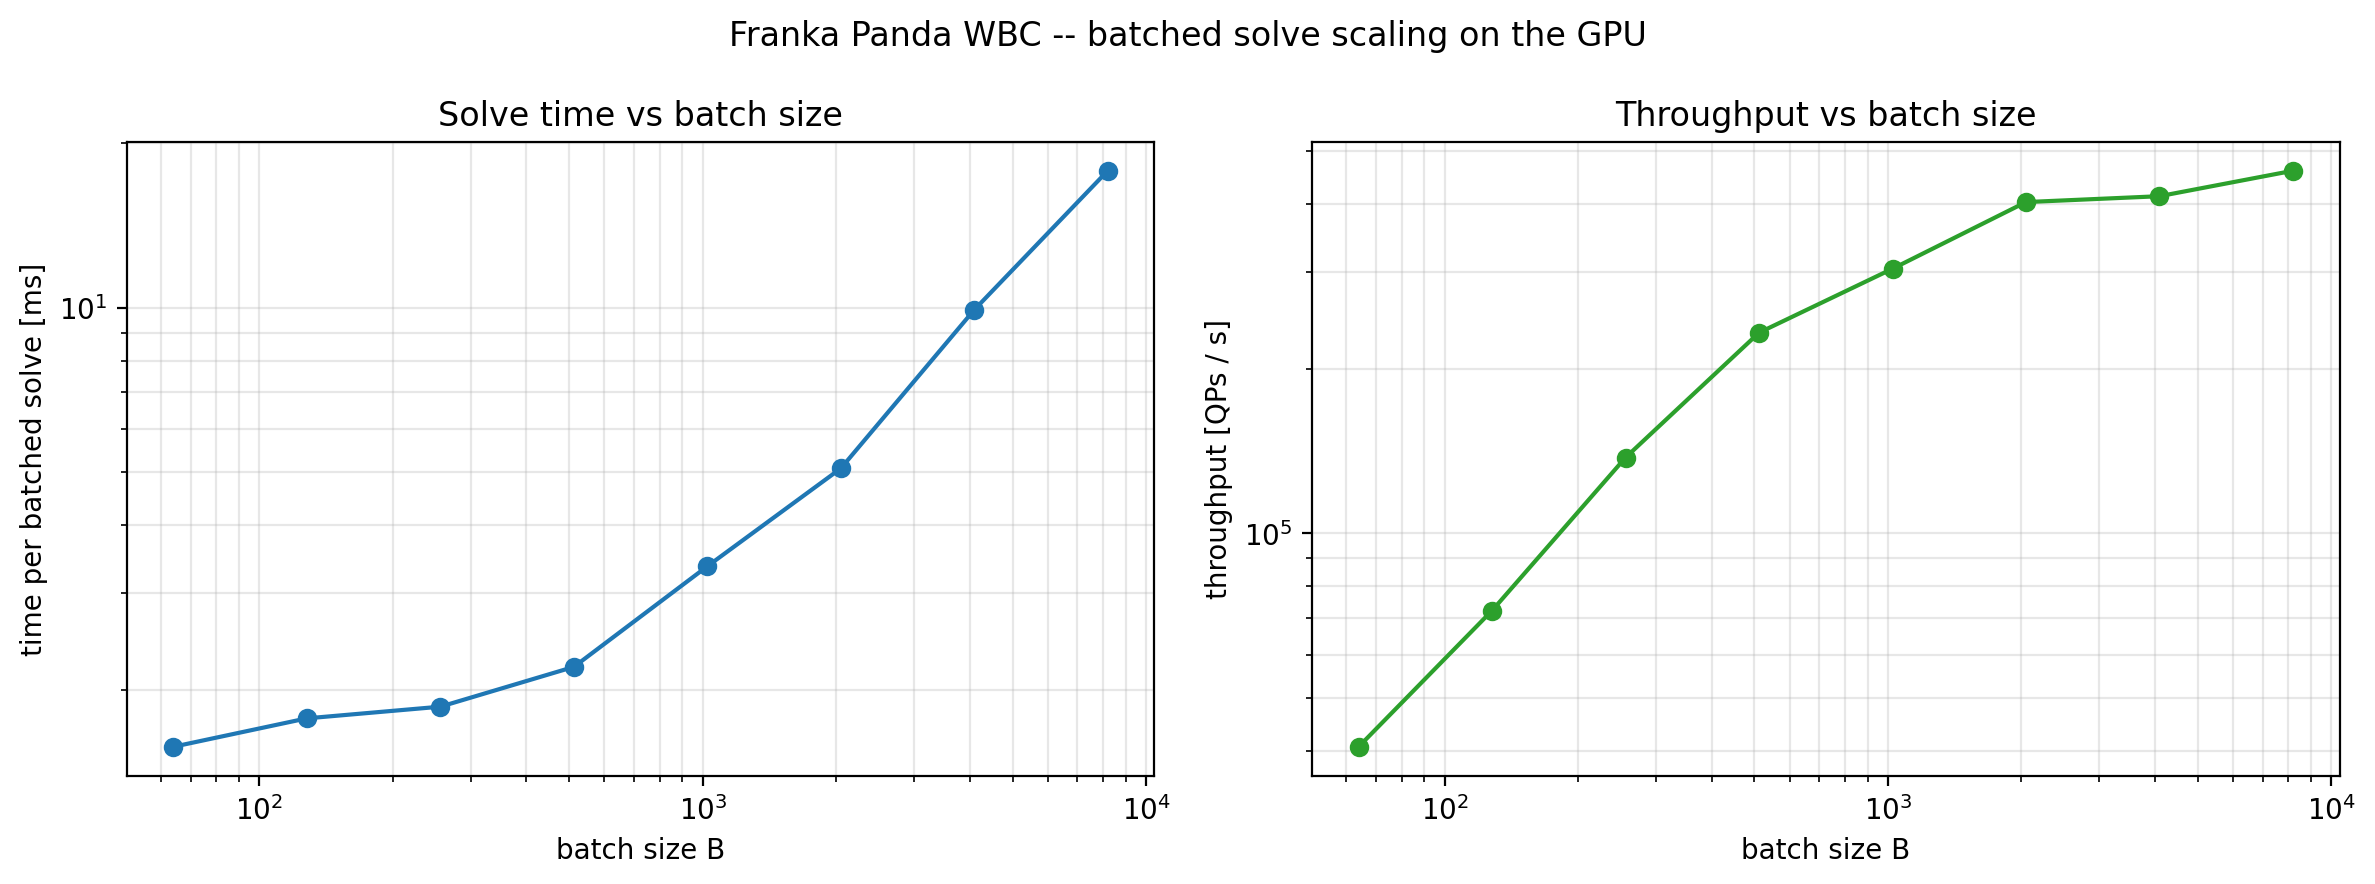

In [10]:
BATCH_SIZES = [64, 128, 256, 512, 1024, 2048, 4096, 8192]

solve_ms, throughput = [], []
for B in BATCH_SIZES:
    solver = DenseSolver()
    solver.settings.verbose = False
    solver.setup(
        P=wbc.P[:B],
        c=wbc.c[:B],
        A=wbc.A[:B],
        b=wbc.b[:B],
        x_l=wbc.x_l,
        x_u=wbc.x_u
        )
    solver.solve()                    # warm-up
    wp.synchronize()
    
    t0 = time.perf_counter()
    solver.solve()
    wp.synchronize()
    dt = (time.perf_counter() - t0) * 1e3
    solve_ms.append(dt)
    throughput.append(B / (dt / 1e3))
    print(f"B={B:6d}:  solve = {dt:8.2f} ms   ->   {throughput[-1]:10.0f} QPs/s")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
axL.loglog(BATCH_SIZES, solve_ms, "o-", color="C0")
axL.set_xlabel("batch size B"); axL.set_ylabel("time per batched solve [ms]")
axL.set_title("Solve time vs batch size"); axL.grid(True, which="both", alpha=0.3)
axR.loglog(BATCH_SIZES, throughput, "o-", color="C2")
axR.set_xlabel("batch size B"); axR.set_ylabel("throughput [QPs / s]")
axR.set_title("Throughput vs batch size"); axR.grid(True, which="both", alpha=0.3)
fig.suptitle("Franka Panda WBC -- batched solve scaling on the GPU")
fig.tight_layout()
plt.show()

## Part 2 -- the closed loop in one CUDA graph

Now the QPs come from a running simulation: `B_SIM` Pandas, each tracking its **own figure-eight**
-- random center, size, plane and period -- with the gripper pointing down, at 500 Hz for 6 s. Every
arm starts at home, and the first second blends smoothly into the figure-eight. Newton's
`SolverMuJoCo` integrates the arms with the torques of the QPs.

The `ClosedLoopSimulation` class below bundles the simulated arms, their `WholeBodyController` and
the logs. Its `step()` runs one control tick for all arms, a fixed sequence of GPU work:

1. `tcp_reference` -- the target of every arm at the current time (our kernel);
2. `wbc.solve(state_0)` -- Newton's dynamics, the WBC QP of every arm (our kernel), and one
   batched solve (cuPIQP);
3. `apply_torques_and_log` -- copy the optimal torques into `control.joint_f` (an arm whose QP did
   not reach the tolerance keeps its previous torques), and log (our kernel);
4. `sim.step(...)` -- integrate one time step (Newton), then copy the new state into `state_0`;
5. `advance` -- increment the tick counter.

The current time lives in a **device** counter, so nothing in the tick reads from or writes to the
host. That lets us record the tick once with `wp.ScopedCapture` -- on the solver's stream, so that
our kernels, Newton and cuPIQP are recorded in order -- and replay the graph with
`wp.capture_launch`. The replays are queued asynchronously; the host waits only once, at the end.
The new state is copied into `state_0` instead of swapping `state_0` and `state_1`, so that every
replay of the graph reads and writes the same arrays.

In [11]:
B_SIM = 1024                 # simulated arms
T_SIM = 6.0                  # seconds
T_RAMP = 1.0                 # blend from home into the figure-eight
N_STEPS = int(round(T_SIM / DT))
FPS = 30
STRIDE = int(round(1 / (FPS * DT)))       # control ticks per logged frame
N_FRAMES = (N_STEPS + STRIDE - 1) // STRIDE

model_sim = build_model(B_SIM)

# Home TCP pose (gripper pointing down) and one figure-eight per arm: random center, size, period,
# and a plane with a random heading, tilted by up to ~30 deg from horizontal.
home = model_sim.state()
home.joint_q.assign(np.tile(Q_HOME, B_SIM))
newton.eval_fk(model_sim, home.joint_q, home.joint_qd, home)
p_home, R_home = wp.zeros(B_SIM, dtype=wp.vec3), wp.zeros(B_SIM, dtype=wp.mat33)
wp.launch(tcp_pose, dim=B_SIM, inputs=[home.body_q], outputs=[p_home, R_home])
P_HOME = p_home.numpy()[0]
rng = np.random.default_rng(1)
center = P_HOME + rng.uniform([-0.15, -0.2, -0.1], [0.0, 0.2, 0.1], (B_SIM, 3))
radius = rng.uniform(0.06, 0.15, B_SIM)
omega = 2 * np.pi / rng.uniform(2.0, 3.0, B_SIM)
heading, tilt = rng.uniform(0, np.pi, B_SIM), rng.uniform(-0.5, 0.5, B_SIM)
e1 = np.stack([np.cos(heading), np.sin(heading), np.zeros(B_SIM)], 1)
e2 = np.stack([-np.sin(heading) * np.cos(tilt), np.cos(heading) * np.cos(tilt), np.sin(tilt)], 1)
figure8 = dict(center=wp.array(center, dtype=wp.vec3), radius=wp.array(radius, dtype=float),
               omega=wp.array(omega, dtype=float), e1=wp.array(e1, dtype=wp.vec3), e2=wp.array(e2, dtype=wp.vec3))


In [12]:

@wp.kernel
def tcp_reference(
    tick: wp.array(dtype=int),        # type: ignore  # current control tick, (1,)
    dt: float,                        # type: ignore  # control period [s]
    t_ramp: float,                    # type: ignore  # duration of the blend from home into the figure-eight [s]
    p_home: wp.vec3,                  # type: ignore  # TCP position at home, where every arm starts
    center: wp.array(dtype=wp.vec3),  # type: ignore  # center of each figure-eight, (B,)
    radius: wp.array(dtype=float),    # type: ignore  # half-width of each figure-eight [m], (B,)
    omega: wp.array(dtype=float),     # type: ignore  # angular frequency of each figure-eight [rad/s], (B,)
    e1: wp.array(dtype=wp.vec3),      # type: ignore  # first unit vector of each figure-eight's plane, (B,)
    e2: wp.array(dtype=wp.vec3),      # type: ignore  # second unit vector of each figure-eight's plane, (B,)
    p_des: wp.array(dtype=wp.vec3),   # type: ignore  # output: desired TCP position p_EE, (B,)
    v_des: wp.array(dtype=wp.vec3),   # type: ignore  # output: desired TCP velocity v_EE, (B,)
    a_ff: wp.array(dtype=wp.vec3),    # type: ignore  # output: feedforward TCP acceleration a_EE, (B,)
):
    """Desired TCP position, velocity and acceleration of every arm at the current tick: a
    figure-eight, blended in from home. Launch with ``dim = B``.
    """
    w = wp.tid()
    t = float(tick[0]) * dt
    u = wp.min(t / t_ramp, 1.0)
    s = u * u * u * (10.0 - 15.0 * u + 6.0 * u * u)        # smooth 0 -> 1 blend and its derivatives
    ds = 30.0 * u * u * (1.0 - u) * (1.0 - u) / t_ramp
    dds = 60.0 * u * (1.0 - u) * (1.0 - 2.0 * u) / (t_ramp * t_ramp)
    om = omega[w]
    x = wp.sin(om * t)
    y = 0.5 * wp.sin(2.0 * om * t)
    dx = om * wp.cos(om * t)
    dy = om * wp.cos(2.0 * om * t)
    shape = center[w] - p_home + radius[w] * (x * e1[w] + y * e2[w])
    dshape = radius[w] * (dx * e1[w] + dy * e2[w])
    ddshape = -radius[w] * om * om * (x * e1[w] + 4.0 * y * e2[w])
    p_des[w] = p_home + s * shape
    v_des[w] = ds * shape + s * dshape
    a_ff[w] = dds * shape + 2.0 * ds * dshape + s * ddshape


@wp.kernel
def apply_torques_and_log(
    x: wp.array2d(dtype=wp.float64),       # type: ignore  # QP solutions [nu_dot; tau] of all arms, (B, 2 na)
    status: wp.array(dtype=wp.int32),      # type: ignore  # solver status of every QP, (B,)
    solved: int,                           # type: ignore  # status value of a solved QP
    tick: wp.array(dtype=int),             # type: ignore  # current control tick, (1,)
    stride: int,                           # type: ignore  # control ticks per logged frame
    joint_q: wp.array(dtype=float),        # type: ignore  # joint positions of all arms, (B * na,)
    body_q: wp.array(dtype=wp.transform),  # type: ignore  # world poses of all bodies
    p_des: wp.array(dtype=wp.vec3),        # type: ignore  # desired TCP position of every arm, (B,)
    joint_f: wp.array(dtype=float),        # type: ignore  # in/out: joint torque command of all arms, (B * na,)
    n_unsolved: wp.array(dtype=int),       # type: ignore  # in/out: number of unsolved arm-ticks, (1,)
    log_err: wp.array2d(dtype=float),      # type: ignore  # output: TCP tracking error [m] per tick, (N_STEPS, B)
    log_q: wp.array2d(dtype=float),        # type: ignore  # output: joint positions per frame, (N_FRAMES, B * na)
    log_tau: wp.array2d(dtype=float),      # type: ignore  # output: joint torques per frame, (N_FRAMES, B * na)
    log_p: wp.array2d(dtype=wp.vec3),      # type: ignore  # output: TCP position per frame, (N_FRAMES, B)
    log_p_des: wp.array2d(dtype=wp.vec3),  # type: ignore  # output: desired TCP position per frame, (N_FRAMES, B)
):
    """Apply the optimal torques of every arm (an unsolved QP keeps the previous torques) and
    log the closed loop. Launch with ``dim = B``.
    """
    w = wp.tid()
    if status[w] == solved:
        for j in range(na):
            joint_f[w * na + j] = float(x[w, na + j])     # tau block of the QP solution
    else:
        wp.atomic_add(n_unsolved, 0, 1)                    # keep the previous torques
    i = tick[0]
    p = wp.transform_point(body_q[w * NB + HAND], TCP_OFFSET)
    log_err[i, w] = wp.length(p - p_des[w])
    if i % stride == 0:                                    # full state at the video frame rate
        f = i // stride
        for j in range(na):
            log_q[f, w * na + j] = joint_q[w * na + j]
            log_tau[f, w * na + j] = joint_f[w * na + j]
        log_p[f, w] = p
        log_p_des[f, w] = p_des[w]


@wp.kernel
def advance(
    tick: wp.array(dtype=int),  # type: ignore  # in/out: control tick counter, (1,)
):
    """Increment the control tick counter. Launch with ``dim = 1``."""
    tick[0] = tick[0] + 1

In [13]:
class ClosedLoopSimulation:
    """Panda arms simulated in Newton, each controlled by the whole-body controller.

    Every arm tracks its own figure-eight (see ``tcp_reference``) with the
    gripper pointing down. ``step()`` runs one control tick of every arm --
    the WBC, then one simulation step -- as GPU work only, without reading
    from or writing to the host, so it can be recorded into a CUDA graph and
    replayed. The current time is a tick counter on the device, and the new
    state of each step is copied into ``state_0`` (instead of swapping
    ``state_0`` and ``state_1``) so that every replay uses the same arrays.

    Parameters
    ----------
    model : newton.Model
        ``B`` Panda arms, one per world, from ``build_model``.
    figure8 : dict of wp.array
        The figure-eight of every arm: ``"center"``, ``"radius"``,
        ``"omega"``, ``"e1"`` and ``"e2"``, each of shape ``(B,)``.
    p_home : np.ndarray
        TCP position at the home posture, shape ``(3,)``.
    R_home : wp.array(dtype=wp.mat33)
        TCP orientation at the home posture of every arm, shape ``(B,)``; held
        throughout.
    t_ramp : float
        Duration of the blend from home into the figure-eight [s].
    n_steps : int
        Number of control ticks to log.
    stride : int
        Control ticks per logged frame.

    Attributes
    ----------
    state_0 : newton.State
        Current state of all arms.
    control : newton.Control
        Joint torque command of all arms, in ``control.joint_f``.
    wbc : WholeBodyController
        The whole-body controller of all arms.
    n_unsolved : wp.array(dtype=int)
        Number of arm-ticks whose QP was not solved, shape ``(1,)``.
    log : dict of wp.array
        ``"err"``: TCP tracking error per tick, ``(n_steps, B)``; ``"q"`` and
        ``"tau"``: joint positions and torques per frame,
        ``(n_frames, B * na)``; ``"p"`` and ``"p_des"``: actual and desired
        TCP position per frame, ``(n_frames, B)``.
    """

    def __init__(self, model, figure8, p_home, R_home, t_ramp, n_steps, stride):
        self.model = model
        self.B = model.articulation_count
        self.figure8 = figure8
        self.p_home = wp.vec3(*p_home)
        self.t_ramp = t_ramp
        self.stride = stride

        self.state_0, self.state_1 = model.state(), model.state()
        self.control = model.control()
        self.sim = newton.solvers.SolverMuJoCo(model)
        self.wbc = WholeBodyController(model)
        wp.copy(self.wbc.R_des, R_home)

        n_frames = (n_steps + stride - 1) // stride
        self.tick = wp.zeros(1, dtype=int)
        self.n_unsolved = wp.zeros(1, dtype=int)
        self.log = dict(err=wp.zeros((n_steps, self.B), dtype=float),
                        q=wp.zeros((n_frames, self.B * na), dtype=float),
                        tau=wp.zeros((n_frames, self.B * na), dtype=float),
                        p=wp.zeros((n_frames, self.B), dtype=wp.vec3),
                        p_des=wp.zeros((n_frames, self.B), dtype=wp.vec3))
        self.reset()

    @property
    def stream(self):
        """The CUDA stream to run ``step()`` on, and to capture it on (the solver's stream)."""
        return self.wbc.solver.stream

    def reset(self):
        """Put every arm back at home, at rest, and restart the clock and the logs' counters."""
        self.state_0.joint_q.assign(np.tile(Q_HOME, self.B))
        self.state_0.joint_qd.zero_()
        self.control.joint_f.zero_()
        self.tick.zero_()
        self.n_unsolved.zero_()

    def step(self):
        """Run one control tick of every arm: the WBC, then one simulation step of ``DT``.

        1. ``tcp_reference`` writes the target of every arm at the current tick;
        2. ``wbc.solve`` evaluates Newton's dynamics, assembles the QPs and
           solves them in one batched call;
        3. ``apply_torques_and_log`` copies the optimal torques into
           ``control.joint_f`` (an arm whose QP was not solved keeps its
           previous torques) and logs;
        4. Newton's solver integrates one step, and the new state is copied
           into ``state_0``;
        5. ``advance`` increments the tick counter.

        The first call sets up the QP solver, which allocates GPU memory, so
        call ``step()`` once before capturing it into a CUDA graph.
        """
        wbc, f8 = self.wbc, self.figure8
        wp.launch(tcp_reference, dim=self.B,
                  inputs=[self.tick, DT, self.t_ramp, self.p_home,
                          f8["center"], f8["radius"], f8["omega"], f8["e1"], f8["e2"]],
                  outputs=[wbc.p_des, wbc.v_des, wbc.a_ff])
        wbc.solve(self.state_0)
        wp.launch(apply_torques_and_log, dim=self.B,
                  inputs=[wbc.solver.result.x, wbc.solver.result.info.status, Status.CUPIQP_SOLVED.value,
                          self.tick, self.stride, self.state_0.joint_q, self.state_0.body_q, wbc.p_des],
                  outputs=[self.control.joint_f, self.n_unsolved, self.log["err"], self.log["q"],
                           self.log["tau"], self.log["p"], self.log["p_des"]])
        self.sim.step(self.state_0, self.state_1, self.control, None, DT)
        self.state_0.assign(self.state_1)
        wp.launch(advance, dim=1, inputs=[self.tick])


closed_loop = ClosedLoopSimulation(model_sim, figure8, P_HOME, R_home, t_ramp=T_RAMP, n_steps=N_STEPS, stride=STRIDE)

### Without a CUDA graph

We run the whole simulation by calling `step()` at every tick. Each call issues the tick's GPU
operations one by one from Python -- Newton's dynamics, our kernels, cuPIQP's solve and Newton's
simulation step, together close to two hundred small launches. The first `step()` sets up the solver
and compiles the kernels, so we run one tick to warm up before timing.

In [14]:
stream = closed_loop.stream
with wp.ScopedStream(stream):
    closed_loop.step()                       # warm-up: sets up the solver and compiles the kernels
    closed_loop.reset()
    wp.synchronize_stream(stream)

    t0 = time.perf_counter()
    for _ in range(N_STEPS):
        closed_loop.step()
    wp.synchronize_stream(stream)
    plain_s = time.perf_counter() - t0

print(f"without CUDA graph: {N_STEPS} ticks in {plain_s:.1f} s, {plain_s / N_STEPS * 1e3:.2f} ms per tick")

without CUDA graph: 3000 ticks in 19.9 s, 6.62 ms per tick


### With a CUDA graph

Now we record one `step()` with `wp.ScopedCapture` -- this records its GPU operations instead of
running them -- and replay the recording with `wp.capture_launch`, once per tick. Every tick is then
a single launch: the CPU no longer issues the operations one by one, and the GPU runs them back to
back. The replays are queued asynchronously, and the host waits only once, at the end.

In [15]:
with wp.ScopedStream(stream):
    closed_loop.reset()
    with wp.ScopedCapture() as capture:
        closed_loop.step()

    t0 = time.perf_counter()
    for _ in range(N_STEPS):
        wp.capture_launch(capture.graph)
    wp.synchronize_stream(stream)
    graph_s = time.perf_counter() - t0

print(f"with CUDA graph:    {N_STEPS} ticks in {graph_s:.1f} s, {graph_s / N_STEPS * 1e3:.2f} ms per tick "
      f"-> {plain_s / graph_s:.1f}x faster")
print(f"{N_STEPS} ticks x {B_SIM} arms = {N_STEPS * B_SIM:,} WBC QPs ({N_STEPS * B_SIM / graph_s:,.0f} QPs/s, "
      f"with the physics);  unsolved: {closed_loop.n_unsolved.numpy()[0]}")

with CUDA graph:    3000 ticks in 11.7 s, 3.91 ms per tick -> 1.7x faster
3000 ticks x 1024 arms = 3,072,000 WBC QPs (261,954 QPs/s, with the physics);  unsolved: 0


Pull the logs to the host once and look at the tracking error (every tick) and the torques of the
arm that came closest to its limits.

TCP tracking error after the ramp: median 1.5 mm, 99th percentile 10.9 mm


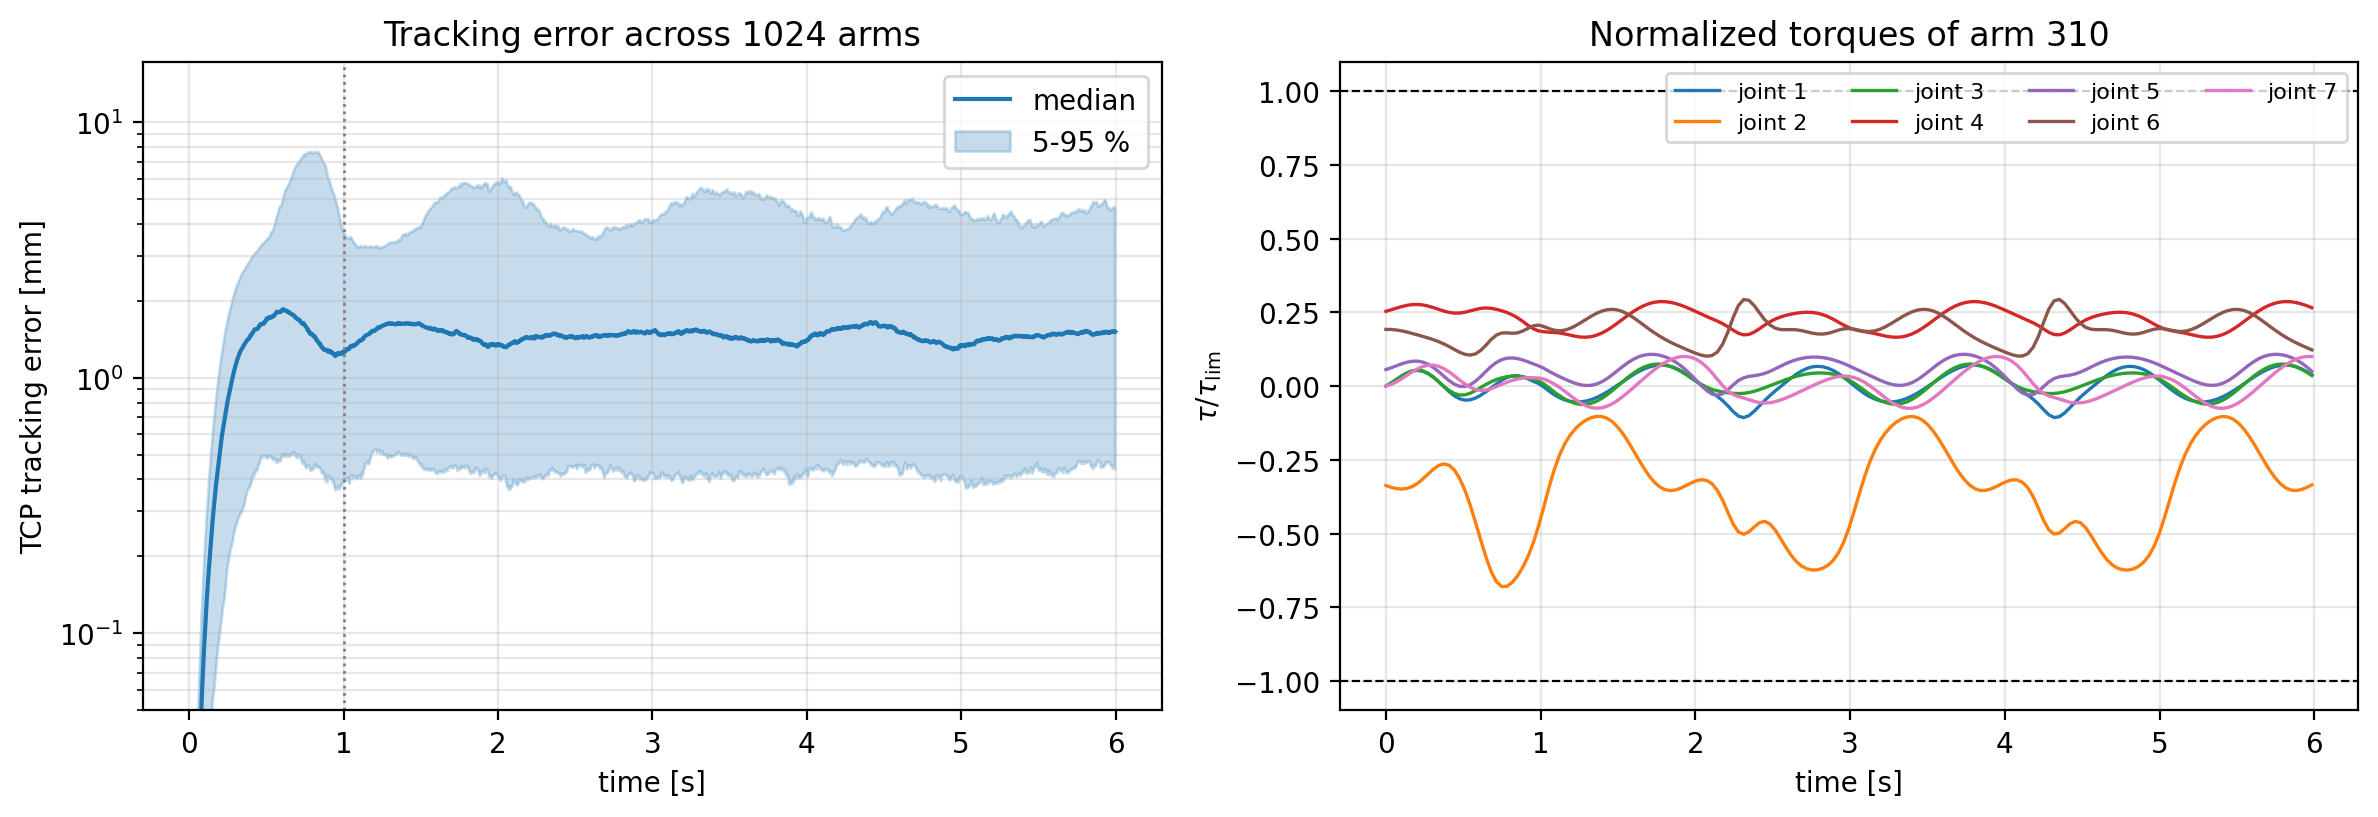

In [16]:
log_np = {k: v.numpy() for k, v in closed_loop.log.items()}
err = log_np["err"]                                      # (N_STEPS, B_SIM) TCP tracking error
after_ramp = slice(int(T_RAMP / DT), None)
print(f"TCP tracking error after the ramp: median {np.median(err[after_ramp]) * 1e3:.1f} mm, "
      f"99th percentile {np.quantile(err[after_ramp], 0.99) * 1e3:.1f} mm")

t = np.arange(N_STEPS) * DT
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2))

ax0.semilogy(t, np.median(err, axis=1) * 1e3, color="C0", label="median")
ax0.fill_between(t, np.quantile(err, 0.05, axis=1) * 1e3, np.quantile(err, 0.95, axis=1) * 1e3,
                 color="C0", alpha=0.25, label="5-95 %")
ax0.axvline(T_RAMP, color="0.5", ls=":", lw=1)
ax0.set_ylim(bottom=0.05)
ax0.set_xlabel("time [s]"); ax0.set_ylabel("TCP tracking error [mm]")
ax0.set_title(f"Tracking error across {B_SIM} arms"); ax0.legend(); ax0.grid(True, which="both", alpha=0.3)

tau = log_np["tau"].reshape(N_FRAMES, B_SIM, na)
k = int(np.argmax((np.abs(tau) / TAU_LIM).max(axis=(0, 2))))     # the arm closest to its limits
t_frames = np.arange(N_FRAMES) * STRIDE * DT
for j in range(na):
    ax1.plot(t_frames, tau[:, k, j] / TAU_LIM[j], lw=1.2, label=f"joint {j + 1}")
ax1.axhline(1, color="k", ls="--", lw=0.8); ax1.axhline(-1, color="k", ls="--", lw=0.8)
ax1.set_xlabel("time [s]"); ax1.set_ylabel(r"$\tau / \tau_{\lim}$")
ax1.set_title(f"Normalized torques of arm {k}"); ax1.legend(ncol=4, fontsize=8); ax1.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Part 3 -- a video with Newton's OpenGL viewer

Newton's viewers draw a model's `State` with `log_state`, plus any points and lines we add, frame by
frame between `begin_frame` and `end_frame`. We replay the logged closed loop in `ViewerGL`, which
renders offscreen -- here headless through EGL, so it also works on a machine without a display --
and `get_frame()` returns each rendered image.

All arms live at the same place in their own worlds; `set_world_offsets` spreads the shown worlds on
a grid for display, and we add the same offsets to the TCP trails (colored), the desired paths
(white) and the current targets (red).

In [17]:
import pyglet
pyglet.options["headless"] = True        # render offscreen through EGL, without a display


def render_frames(worlds, camera, width=1280, height=720, trail_seconds=2.0):
    """Render the logged closed loop of some arms with Newton's OpenGL viewer.

    Parameters
    ----------
    worlds : sequence of int
        Arms (worlds) to show. They are laid out on a grid, 1 m apart.
    camera : tuple
        Camera position (``wp.vec3``), pitch and yaw [deg], as taken by
        ``ViewerGL.set_camera``.
    width, height : int
        Image size [pixels].
    trail_seconds : float
        Length of the TCP trails [s].

    Returns
    -------
    list of np.ndarray
        One RGB image of shape ``(height, width, 3)`` per logged frame.
    """
    worlds = np.asarray(worlds)
    viewer = newton.viewer.ViewerGL(width=width, height=height, headless=True)
    viewer.set_model(model_sim)
    viewer.set_visible_worlds(worlds.tolist())
    viewer.set_world_offsets((1.0, 1.0, 0.0))
    viewer.set_camera(*camera)
    offsets = viewer.world_offsets.numpy()[worlds]                     # (n, 3)
    arm_colors = matplotlib.colormaps["turbo"](np.linspace(0.08, 0.92, len(worlds)))[:, :3]
    trail = int(trail_seconds * FPS)
    replay_state = model_sim.state()
    vec3 = lambda a: wp.array(np.ascontiguousarray(a, dtype=np.float32).reshape(-1, 3), dtype=wp.vec3)

    frames = []
    for f in range(N_FRAMES):
        replay_state.joint_q.assign(log_np["q"][f])
        newton.eval_fk(model_sim, replay_state.joint_q, replay_state.joint_qd, replay_state)
        viewer.begin_frame(f * STRIDE * DT)
        viewer.log_state(replay_state)
        idx = np.arange(max(0, f - trail), f + 1)
        if len(idx) > 1:
            for name, data, colors, line_width in (("desired", log_np["p_des"], np.ones_like(arm_colors), 0.003),
                                                   ("trails", log_np["p"], arm_colors, 0.008)):
                path = data[idx][:, worlds] + offsets                     # (T, n, 3)
                seg_colors = np.repeat(colors[None], len(idx) - 1, axis=0)
                viewer.log_lines(name, vec3(path[:-1]), vec3(path[1:]), vec3(seg_colors), line_width)
        viewer.log_points("targets", vec3(log_np["p_des"][f, worlds] + offsets), 0.015,
                          vec3(np.tile([1.0, 0.15, 0.1], (len(worlds), 1))))
        viewer.end_frame()
        frames.append(viewer.get_frame().numpy())
    viewer.close()
    return frames

Render 24 of the arms, show the video here, and save it as an MP4 file.

In [18]:
frames = render_frames(worlds=range(16), camera=(wp.vec3(-4.0, -4.0, 2.8), -27.0, 45.0))   # position, pitch, yaw [deg]
media.show_video(frames, fps=FPS, width=960)

os.makedirs("videos", exist_ok=True)
media.write_video("videos/batched_wbc_panda.mp4", frames, fps=FPS)
print(f"saved videos/batched_wbc_panda.mp4 ({os.path.getsize('videos/batched_wbc_panda.mp4') / 1e6:.1f} MB)")

This browser does not support the video tag.


saved videos/batched_wbc_panda.mp4 (0.9 MB)
